# Ocean heat content in 2-D — alternate spin-ups vs Full-CPL

Where the FC-FOSI spin-ups store heat differently from FC, horizontally and in latitude–depth. Complements the
global-mean views of `4_ohc_compare_analysis` (layer time series, depth–time Hovmöller) and `15_ohc_ts_ctrl_analysis`
(FC layers, 0–2500).

**1 Horizontal — ΔOHC maps.** MPAS-Analysis remapped `deltaOHC` climatologies (heat content of a layer relative to model
year 1, GJ m⁻²) over the last `CLIMO_LEN` years of `YEARS` (0301–0350), one row per layer in `MAP_LAYERS`: FC, then
FC-FOSI − FC, stippled where the difference exceeds the piControl spread of the same field (same test and settings as
the SST/SSS maps of `7_ocn_map_compare_analysis`). FC-FOSI-S1/S2 fail the climatology window check (MPAS-Analysis also
averaged other years in, see the Derived cell) and `deltaOHC` has no replacement on disk, so they are used as they are
and flagged.

**2 Zonal — latitude–depth section.** For each latitude band and level, the heat content per metre of depth and per degree
of latitude, H = ρ₀ c_p Σ_lon(T·h·A) / (Δz·Δlat) [J m⁻¹ deg⁻¹] (ρ₀ = 1026 kg m⁻³, c_p = 3996 J kg⁻¹ K⁻¹ as in
MPAS-Analysis), from the remapped 0.5° decadal climatologies `post/time_series/ocn_2d/<case>_ANN_YYYY01_YYYY12_climo.nc`.
Each row: FC over the window minus FC over `BASELINE`, then FC-FOSI − FC over the window. Integrated, the panels give the
global ΔOHC of `4_ohc_compare_analysis` within ~4 %. FC's decadal climatologies end at year 250 and the piControl has none,
so `WINDOWS` must lie within years 1–250 and there is no stippling; the default 0201–0250 is the last 50 years all runs
cover (FC-FOSI fully coupled again from year 221; FOSI segments S1 11–20, 81–90, 151–160, S2 11–50).

Figures go to `FIG_DIR` (public_html), caches to `DATA_DIR`.

In [ ]:
import os, sys
WF_ROOT = os.path.abspath("..")            # coupled_spinup_eval/
if WF_ROOT not in sys.path:
    sys.path.insert(0, WF_ROOT)
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
%matplotlib inline

import matplotlib.pyplot as plt

from util.climo_maps import Surface2DClimoPlotter, arrange_panel_grid, climo_window_error
from util.experiments import make_run_dict
from util.figures import publish
from util.ohc_zonal import ZonalOHCSection

## Setup

In [ ]:
# ---- paths ----
MODEL_ROOT   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/E3SMv3_testings"     # case directories
OUTPUT_ROOT  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3spinup_paper"   # published figures/ and data/
OUTPUT_URL   = "https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper"
FIG_DIR      = f"{OUTPUT_ROOT}/figures/ohc_2d"
DATA_DIR     = f"{OUTPUT_ROOT}/data/ohc_2d"                # cached/derived data (index: data/README.md)
DEPTH_FILE   = f"{OUTPUT_ROOT}/data/grid/depth.nc"         # MPAS-Ocean refBottomDepth (level depths)

# ---- experiments: case directory names (under MODEL_ROOT) and model-year periods ----
EXPERIMENTS = {
    "Full-CPL": {
        "spin-up":   {"name": "20231209.v3.LR.piControl-spinup.chrysalis",      "period": "0001-2000"},
        "piControl": {"name": "v3.LR.piControl",                                "period": "0001-0500"},
    },
    "AltBG1": {
        "spin-up":   {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240707.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
    "AltBG2": {
        "spin-up":   {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0001-0220"},
        "piControl": {"name": "20240818.v3.LR.piControl.Rerun.GC2BC.chrysalis", "period": "0221-0350"},
    },
}
LABEL = {"Full-CPL": "FC", "AltBG1": "FC-FOSI-S1", "AltBG2": "FC-FOSI-S2", "AltBG3": "FC-FOSI-S3"}
EXPS  = ["Full-CPL", "AltBG1", "AltBG2"]   # experiments compared; the first is the reference

# ---- 1 horizontal: ΔOHC maps (MPAS-Analysis) ----
YEARS      = (1, 350)       # selects the MPAS-Analysis ts_0001-0350 run
CLIMO_LEN  = 50             # its climatology length (climo_0301-0350)
MESH       = "IcoswISC30E3r5"                  # MPAS-Ocean mesh name in the remapped-climatology folders
MAP_LAYERS = ["OHC_0-700m", "OHC_700-2000m", "OHC_2000m-bottom", "OHC_0-bottom"]   # rows, see OHC_MAPS

# significance of the map differences (stippled where significant), as in 7_ocn_map_compare_analysis
SIG_TEST   = True
SIG_METHOD = "control"      # t-test against the piControl spread of CLIMO_LEN-yr means
SIG_ALPHA  = 0.05
SIG_FDR    = False          # pointwise (FDR control with df = 9 stipples nothing on ~1.6e5-point maps)
SIG_MIN_LEVEL = True        # stipple only differences at least the lowest colour level
CTRL_EXP   = EXPERIMENTS["Full-CPL"]["piControl"]["name"]   # piControl: samples of internal variability
CTRL_YEARS = (1, 500)       # split into non-overlapping CLIMO_LEN-yr climatologies

# ---- 2 zonal: latitude-depth sections (decadal ocn_2d climatologies) ----
CLIMO_SUBDIR = "post/time_series/ocn_2d"   # under MODEL_ROOT/<case>/
WINDOWS  = [(201, 250)]     # one figure row per window (whole decades, years 1-250: FC climatologies end at 250),
                            # e.g. [(51, 100), (151, 200), (201, 250)] to follow the differences in time
BASELINE = (1, 10)          # first panel of a row: FC window minus FC over these years

# ---- I/O ----
ENGINE = "netcdf4"
DTYPE  = "float32"

In [ ]:
# Derived from Setup — nothing to edit here
run_dict = make_run_dict(EXPERIMENTS, MODEL_ROOT)
CASES    = [run_dict[t]["spin-up"]["name"] for t in EXPS]
LABELS   = [LABEL[t] for t in EXPS]
REF_IDX, TGT_IDX = 0, list(range(1, len(EXPS)))

YEAR_TOKEN = f"{YEARS[0]:04d}-{YEARS[1]:04d}"
CLIM_YEARS = (max(YEARS[0], YEARS[1] - CLIMO_LEN + 1), YEARS[1])          # e.g. (301, 350)
CTRL_WINDOWS = [(y, y + CLIMO_LEN - 1) for y in range(CTRL_YEARS[0], CTRL_YEARS[1], CLIMO_LEN)]

def mpas_analysis_subdir(kind):
    """post/analysis/mpas_analysis/ts_<YEARS>_climo_<CLIM_YEARS>/<kind> of an MPAS-Analysis run."""
    return (f"post/analysis/mpas_analysis/ts_{YEAR_TOKEN}"
            f"_climo_{CLIM_YEARS[0]:04d}-{CLIM_YEARS[1]:04d}/{kind}")

def climo_token(y0, y1):
    """YYYY01_YYYY12 date range of MPAS-Analysis climatology file names."""
    return f"{y0:04d}01_{y1:04d}12"

# Does each experiment's MPAS-Analysis climatology average exactly CLIM_YEARS? (its MOC climatology
# vs. the monthly MOC time series; all variables of a climatology come from the same averaging step)
CLIMO_OK = {}
for case, label in zip(CASES, LABELS):
    err = climo_window_error(
        os.path.join(MODEL_ROOT, case, mpas_analysis_subdir(
            f"clim/mpas/avg/mocStreamfunction_years{CLIM_YEARS[0]:04d}-{CLIM_YEARS[1]:04d}.nc")),
        os.path.join(MODEL_ROOT, case, mpas_analysis_subdir(f"timeseries/moc/mocTimeSeries_{YEAR_TOKEN}.nc")),
        CLIM_YEARS)
    CLIMO_OK[case] = err < 0.01
    print(f"{label:11s} MPAS-Analysis climatology vs {CLIM_YEARS} time-series mean: max {err:.3f} Sv -> "
          + ("ok" if CLIMO_OK[case] else "NOT the CLIM_YEARS mean (other years averaged in)"))

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
publish(OUTPUT_ROOT, FIG_DIR)
print("figures ->", FIG_DIR)
print("data    ->", DATA_DIR)
print("web     ->", FIG_DIR.replace(OUTPUT_ROOT, OUTPUT_URL))

## 1 Horizontal: ΔOHC maps
### Settings
Map style of the SST/SSS maps in `7_ocn_map_compare_analysis` with a diverging colormap. Difference levels: the white
band is below the typical smallest significant difference (median t·√2·s of the piControl spread: 0.5, 0.4, 0.6,
1.3 GJ m⁻² for the four layers), the top level about the 99th percentile of |FC-FOSI − FC| (1.4, 1.9, 2.7,
4.2 GJ m⁻²), extend="both" for the rest. `COMBINED` lays the `MAP_LAYERS` rows out on one page.

In [ ]:
MAP_STYLE = dict(
    field="annual_mean",                     # climo files are already annual means
    cmap="RdBu_r",
    extend="both",
    cbar_tick_every=2,
    diff_tick_every=1,                       # label every (non-uniform) difference level
    diff_cmap="bwr",
    diff_extend="both",
    figsize=(24, 6),
    fontz=16.0,
    sig_grid=(72, 36),                       # stipple dots per panel (every 5°)
    sig_dot_size=4.0,                        # dot size (points², on the 24-in wide figure)
)

OHC_UNIT = r"GJ m$^{-2}$"
OHC_MAPS = {   # layer = MPAS-Analysis remap folder deltaOHC_<layer>_<MESH>_to_0.5x0.5degree
    "OHC_0-700m":       dict(layer="0-700m",      label=r"$\Delta$OHC 0–700 m",
                             clevs=list(range(-8, 9)),
                             diff_clevs=[-2, -1.5, -1, -0.75, -0.5, -0.25, 0.25, 0.5, 0.75, 1, 1.5, 2]),
    "OHC_700-2000m":    dict(layer="700-2000m",   label=r"$\Delta$OHC 700–2000 m",
                             clevs=list(range(-10, 11)),
                             diff_clevs=[-2, -1.5, -1, -0.75, -0.5, -0.25, 0.25, 0.5, 0.75, 1, 1.5, 2]),
    "OHC_2000m-bottom": dict(layer="2000-10000m", label=r"$\Delta$OHC 2000 m–bottom",
                             clevs=list(range(-10, 11)),
                             diff_clevs=[-3, -2, -1.5, -1, -0.5, -0.25, 0.25, 0.5, 1, 1.5, 2, 3]),
    "OHC_0-bottom":     dict(layer="0-10000m",    label=r"$\Delta$OHC 0–bottom",
                             clevs=list(range(-20, 21, 2)),
                             diff_clevs=[-5, -4, -3, -2, -1, -0.5, 0.5, 1, 2, 3, 4, 5]),
}

COMBINED = dict(                # all lengths in inches (as the combined figure of 7_ocn_map_compare_analysis)
    width=24.0,                 # figure width; the height follows from the panel shape
    aspect=0.5,                 # panel height / width (global lat-lon maps)
    fontz=16.0,                 # tick-label size of every row
    left=1.2,                   # room for the latitude labels
    col_gaps=(1.7, 0.7),        # after the reference column (its colorbar) / between the difference panels
    right=1.7,                  # after the last column (shared difference colorbar)
    top=0.6,
    row_gap=1.3,                # room for x labels and the next row's titles
    bottom=0.9,
    cbar_frac=0.95,             # colorbar height / panel height
    print_width=6.5,            # width of the figure in print: fonts, lines and dots shrink by print_width / width
    print_dot=1.0,              # stipple dot diameter in print (pt)
    sig_grid=(72, 36),          # stipple dots per panel, same in every row
)

### Compute & plot

web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_2d/mpaso_ANN_030101_035012_climo.nc_compare_OHC_0-bottom_ANN.pdf


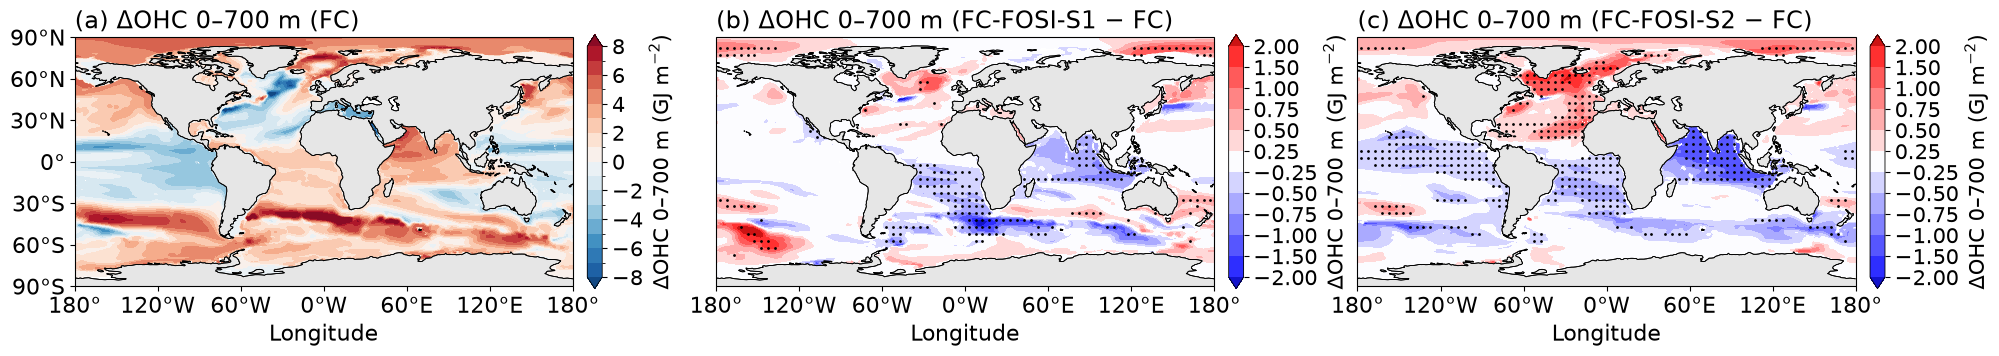

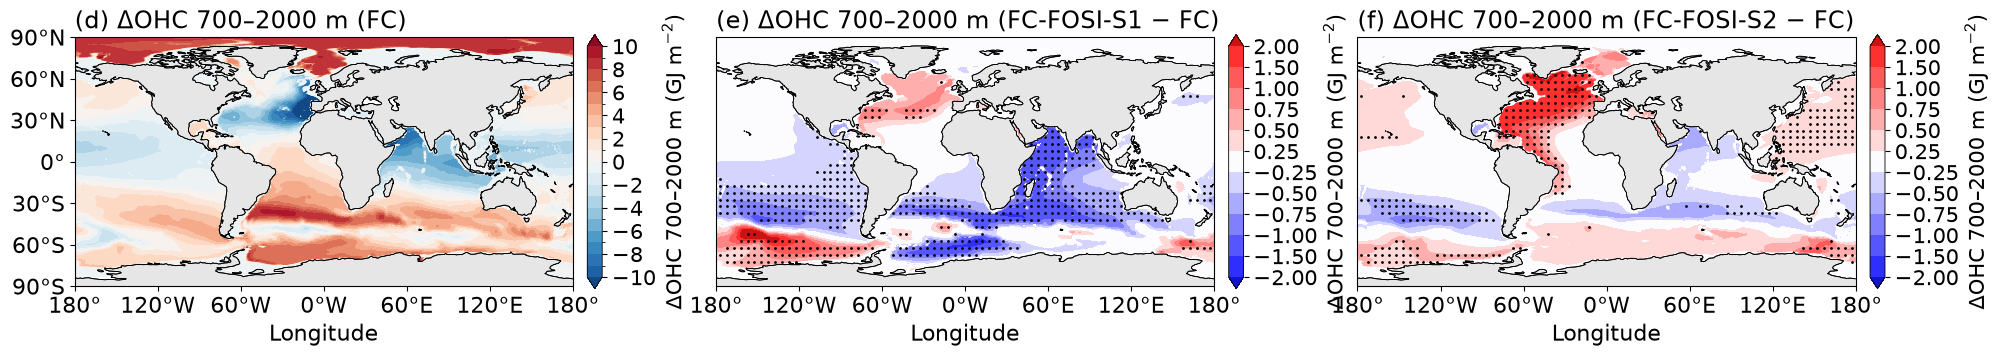

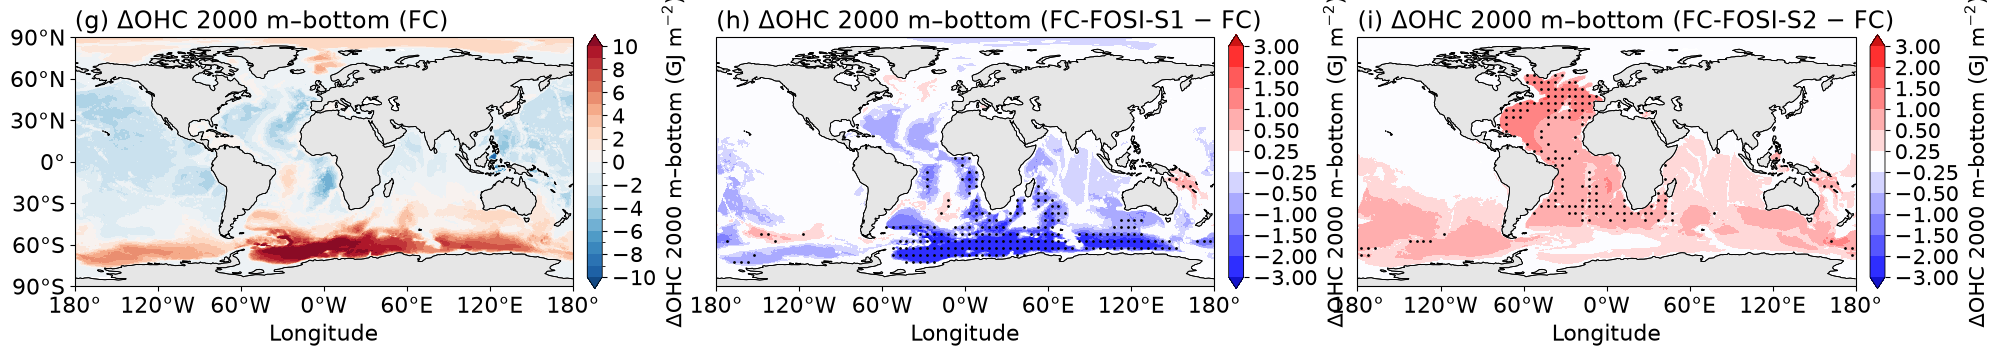

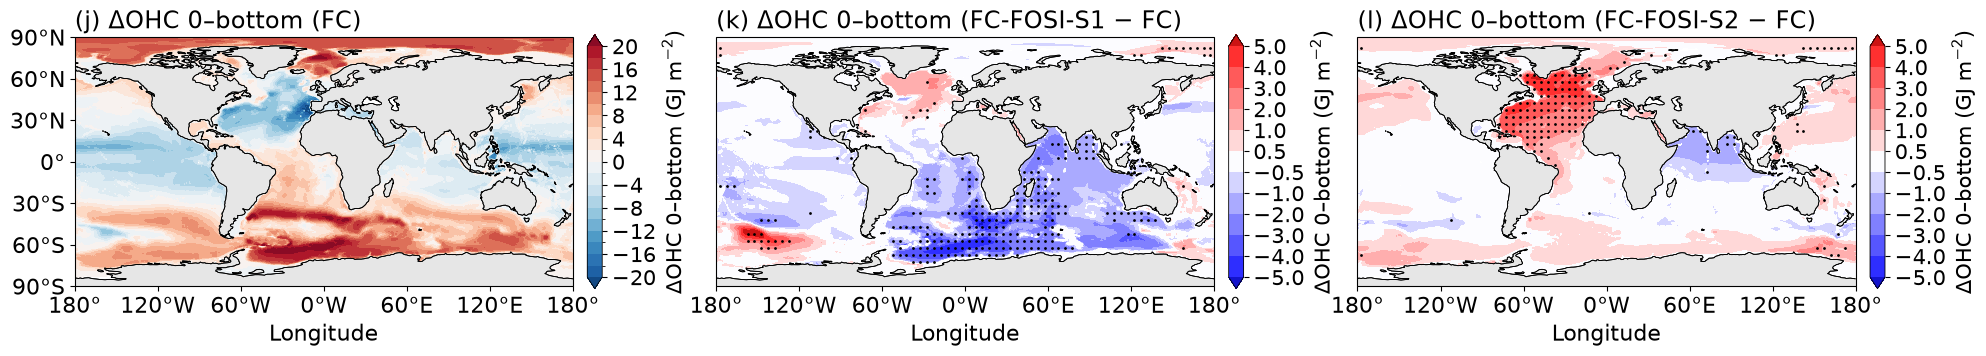

In [5]:
bad = [label for case, label in zip(CASES, LABELS) if not CLIMO_OK[case]]
if bad:
    print(f"WARNING: the MPAS-Analysis climatology of {', '.join(bad)} is not the {CLIM_YEARS} mean "
          "(other years averaged in, see the Derived cell); deltaOHC has no replacement on disk.")
file_key = f"mpaso_ANN_{climo_token(*CLIM_YEARS)}_climo.nc"
ohc_plotters, ohc_plot_kw = {}, {}
for row, name in enumerate(MAP_LAYERS):
    cfg = OHC_MAPS[name]
    remap = f"deltaOHC_{cfg['layer']}_{MESH}_to_0.5x0.5degree"
    plotter = Surface2DClimoPlotter(
        root_dir=MODEL_ROOT, sub_dir=None, file_key=file_key, engine=ENGINE, dtype=DTYPE,
        target_res=(0.5, 0.5), area_weighted=True, use_cartopy=True,
    )
    for case, label in zip(CASES, LABELS):
        plotter.add_experiment(exp=case, var_prefer="deltaOHC", label=label, year_token=YEAR_TOKEN,
                               sub_dir=mpas_analysis_subdir(f"clim/mpas/avg/remapped/{remap}"))
    if SIG_TEST:
        plotter.add_control_climo(
            CTRL_EXP,
            [f"mpaso_ANN_{climo_token(*w)}_climo.nc" for w in CTRL_WINDOWS],
            f"post/analysis/mpas_analysis/*/clim/mpas/avg/remapped/{remap}",
            "deltaOHC",
        )

    cache_nc = os.path.join(DATA_DIR, f"{file_key}_cache_{name}_ANN.nc")
    plotter.save_surface2d_cache(cache_nc, fields=("annual_mean",))
    print("Saved cache:", cache_nc)

    kw = dict(
        MAP_STYLE,
        var_label=cfg["label"],
        ref_idx=REF_IDX,
        tgt_idx=TGT_IDX,
        fig_idx=3 * row,                     # panel letters continue down the rows
        clevs=cfg["clevs"],
        diff_clevs=cfg["diff_clevs"],
        cbar_label=f"{cfg['label']} ({OHC_UNIT})",
        diff_label=f"{cfg['label']} ({OHC_UNIT})",
        sig_test=SIG_TEST,
        sig_method=SIG_METHOD,
        sig_alpha=SIG_ALPHA,
        sig_fdr=SIG_FDR,
        sig_min_diff=min(l for l in cfg["diff_clevs"] if l > 0) if SIG_MIN_LEVEL else None,
    )
    out = os.path.join(FIG_DIR, f"{file_key}_compare_{name}_ANN.pdf")
    plotter.plot_map_compare(**kw, save=out)
    ohc_plotters[name], ohc_plot_kw[name] = plotter, kw
    print("web:", out.replace(OUTPUT_ROOT, OUTPUT_URL))

publish(FIG_DIR, DATA_DIR)

### Combined figure
All `MAP_LAYERS` rows on one grid (`arrange_panel_grid`, as the combined figure of `7_ocn_map_compare_analysis`): equal
panels, aligned columns, one colorbar for the reference and one shared by the difference panels of each row.

/home/ac.szhang/.conda/envs/zppy-pcmdi-diags/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/ac.szhang/.conda/envs/zppy-pcmdi-diags/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/ac.szhang/.conda/envs/zppy-pcmdi-diags/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/ac.szhang/.conda/envs/zppy-pcmdi-diags/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_2d/ohc_map_compare_0-700m_700-2000m_2000m-bottom_0-bottom_ANN.pdf


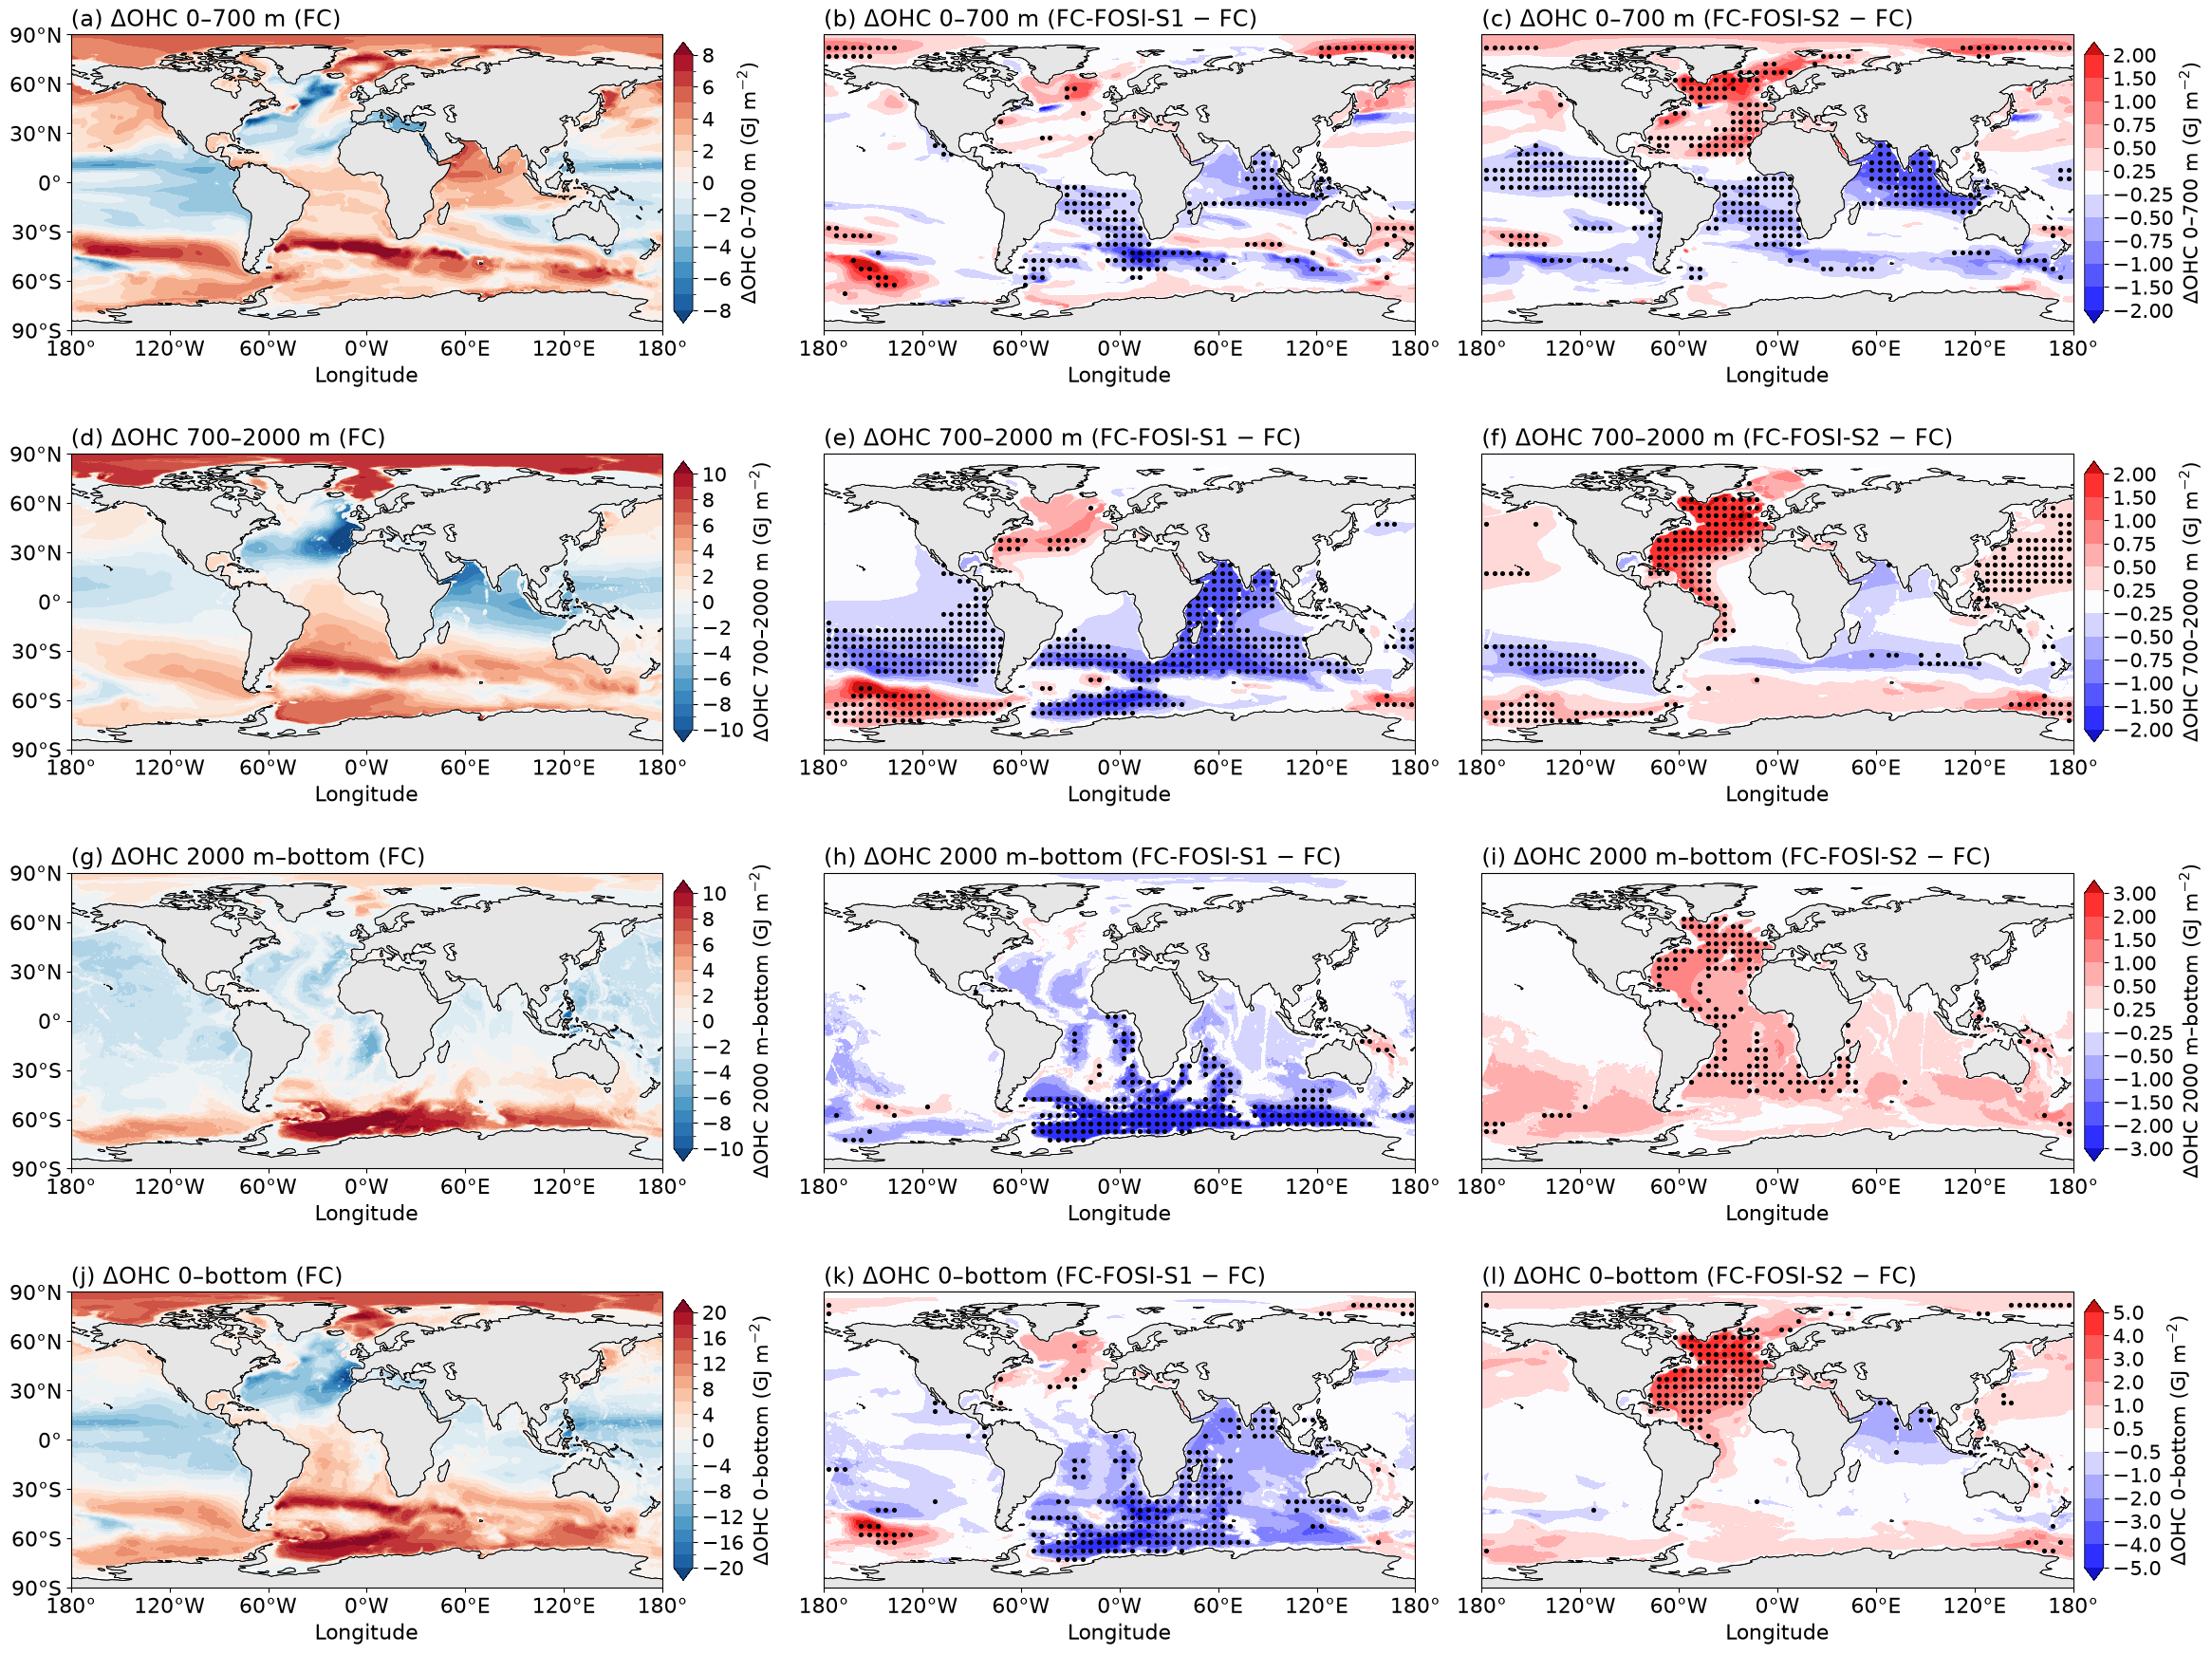

In [6]:
# stipple dots of print_dot pt diameter once the figure is scaled to print_width, same grid in all rows
dots = dict(sig_grid=COMBINED["sig_grid"],
            sig_dot_size=(COMBINED["print_dot"] * COMBINED["width"] / COMBINED["print_width"]) ** 2)
layout = {k: COMBINED[k] for k in ("width", "aspect", "left", "col_gaps", "right", "top", "row_gap",
                                   "bottom", "cbar_frac")}

fig = plt.figure()
slots = fig.add_gridspec(len(MAP_LAYERS), 1)   # provisional; arrange_panel_grid sets the final positions
for row, name in enumerate(MAP_LAYERS):
    ohc_plotters[name].plot_map_compare(**{**ohc_plot_kw[name], "fontz": COMBINED["fontz"], **dots},
                                        diff_cbar="shared", fig=fig, slot=slots[row])
arrange_panel_grid(fig, [ohc_plotters[name].last_axes for name in MAP_LAYERS], **layout)

comb_out = os.path.join(FIG_DIR, f"ohc_map_compare_{'_'.join(n.removeprefix('OHC_') for n in MAP_LAYERS)}_ANN.pdf")
fig.savefig(comb_out, dpi=300, bbox_inches="tight")

publish(FIG_DIR, DATA_DIR)
print("web:", comb_out.replace(OUTPUT_ROOT, OUTPUT_URL))

## 2 Zonal: latitude–depth sections
One section per case and window (plus FC over `BASELINE`), cached in `DATA_DIR` as `ohc_zonal_<case>_<years>.nc`
(~17 s per decadal climatology on first use; `FORCE = True` rebuilds).

In [7]:
FORCE = False
zon = ZonalOHCSection(MODEL_ROOT, DEPTH_FILE, DATA_DIR, sub_dir=CLIMO_SUBDIR, engine=ENGINE)

base = zon.section(CASES[0], BASELINE, force=FORCE)
H = {(case, w): zon.section(case, w, force=FORCE) for w in WINDOWS for case in CASES}

for w in WINDOWS:
    fc = H[(CASES[0], w)]
    total = float(((fc - base) * zon.dz[None, :] * 0.5).sum()) / 1e22     # 0.5° bands
    print(f"{w[0]:04d}-{w[1]:04d}: FC ΔOHC since {BASELINE[0]:04d}-{BASELINE[1]:04d} = {total:.1f} x1e22 J; "
          + ", ".join(f"{lab} - FC = {float(((H[(c, w)] - fc) * zon.dz[None, :] * 0.5).sum()) / 1e22:+.2f}"
                      for c, lab in zip(CASES[1:], LABELS[1:])) + " x1e22 J")
publish(DATA_DIR)

0201-0250: FC ΔOHC since 0001-0010 = 23.8 x1e22 J; FC-FOSI-S1 - FC = -17.64, FC-FOSI-S2 - FC = +13.57 x1e22 J


### Settings
Colour levels: FC's anomaly since 0001–0010 reaches about ±30 × 10¹⁸ J m⁻¹ deg⁻¹ (0201–0250; 99th percentile 27);
the differences have a median of 0.3–0.6 and a 99th percentile of 4.3–4.8, so the white band is below 0.5 and the
top level 5, extend="both" for the rest.

In [8]:
ZONAL_STYLE = dict(
    scale=1e18,
    unit=r"$10^{18}$ J m$^{-1}$ deg$^{-1}$",
    ref_levels=[-30, -25, -20, -15, -10, -5, -2, 2, 5, 10, 15, 20, 25, 30],
    diff_levels=[-5, -4, -3, -2, -1, -0.5, 0.5, 1, 2, 3, 4, 5],
    ref_cmap="RdBu_r",
    diff_cmap="RdBu_r",
    ylim_km=(0.0, 5.5),
    lat_band=(-80.0, 90.0),
    fontz=14.0,
)

### Plot

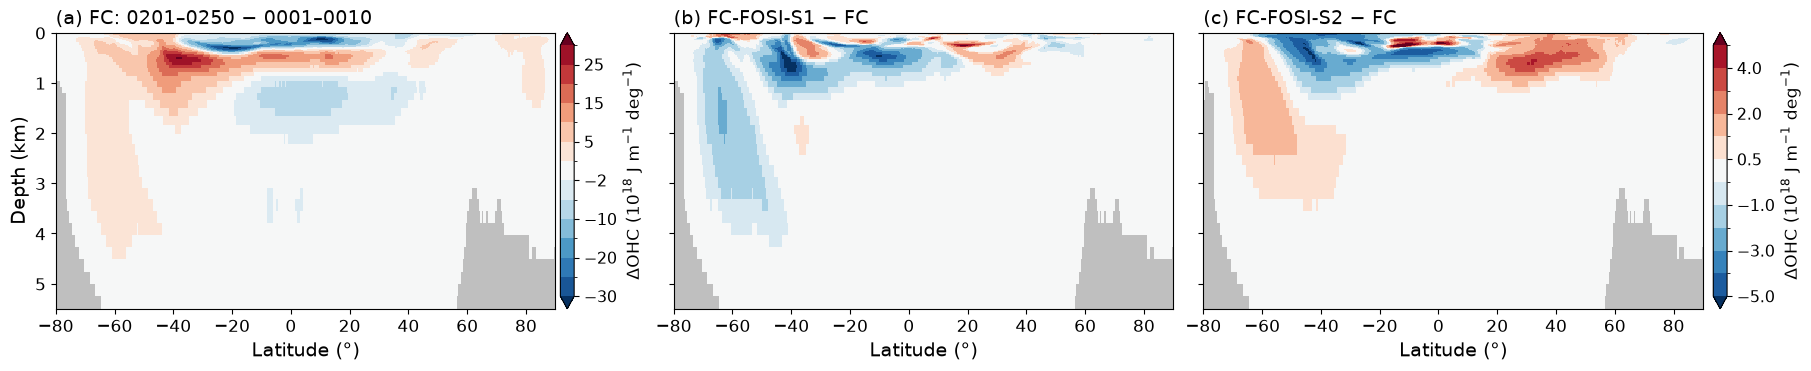

web: https://web.lcrc.anl.gov/public/e3sm/diagnostic_output/ac.szhang/v3spinup_paper/figures/ohc_2d/ohc_zonal_compare_0201-0250.pdf


In [9]:
rows = [dict(window=w, baseline=BASELINE,
             ref=H[(CASES[0], w)] - base,
             diffs=[H[(c, w)] - H[(CASES[0], w)] for c in CASES[1:]])
        for w in WINDOWS]
tag = "_".join(f"{w[0]:04d}-{w[1]:04d}" for w in WINDOWS)
out = os.path.join(FIG_DIR, f"ohc_zonal_compare_{tag}.pdf")
fig, axes = zon.plot_compare(rows, LABELS, **ZONAL_STYLE, save=out)
plt.show()

publish(FIG_DIR, DATA_DIR)
print("web:", out.replace(OUTPUT_ROOT, OUTPUT_URL))